In [1]:
# Week 5 – Damage Severity Classification
# Objective: Train a CNN to classify damage severity


In [2]:
# Step 1: Imports

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os


In [3]:
# Step 2: Load Dataset using TensorFlow

DATASET_PATH = "cropped_damage"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("✅ Dataset loaded successfully")
print("Class names:", train_ds.class_names)


Found 195 files belonging to 3 classes.
Using 156 files for training.
Found 195 files belonging to 3 classes.
Using 39 files for validation.
✅ Dataset loaded successfully
Class names: ['minor', 'moderate', 'severe']


In [4]:
# Step 3: Build CNN Model
# Keep it simple and interpretable

model = models.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3 severity classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [5]:
# Step 4: Train Model

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.3654 - loss: 7.9085 - val_accuracy: 0.2308 - val_loss: 2.1736
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.2885 - loss: 1.4656 - val_accuracy: 0.4615 - val_loss: 1.0691
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.4487 - loss: 1.0655 - val_accuracy: 0.4872 - val_loss: 1.0174
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.4487 - loss: 1.0203 - val_accuracy: 0.5385 - val_loss: 1.0063
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.6603 - loss: 0.8517 - val_accuracy: 0.5641 - val_loss: 0.9792
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.6410 - loss: 0.7483 - val_accuracy: 0.5128 - val_loss: 1.0462
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.8654 - loss: 0.6094 - val_accuracy: 0.4872 - val_loss: 1.1765
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.8077 - loss: 0.4775 - val_accuracy: 0.5385 - val_loss:

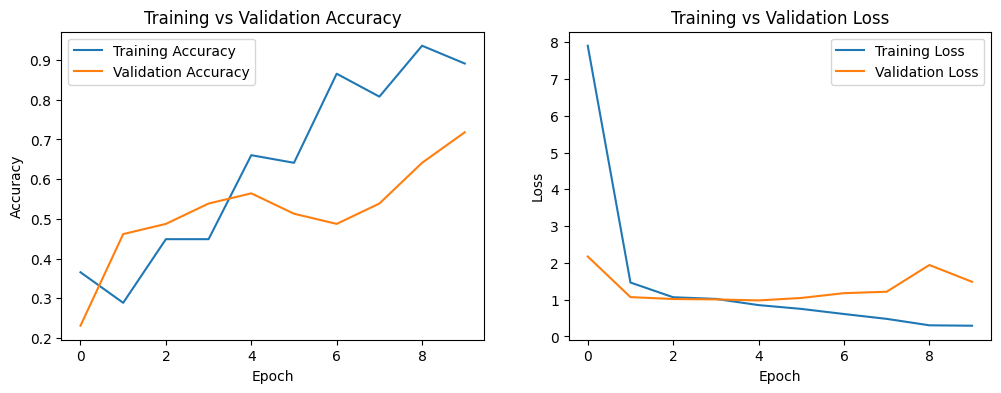

In [6]:
# Step 5: Evaluation

plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


In [8]:
save_path = "severity_model.h5"
model.save(save_path)

NameError: name 'history' is not defined

NameError: name 'history' is not defined

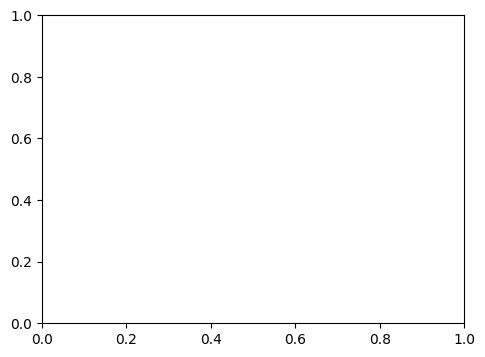

In [9]:
# =========================
# Reflection
# =========================

# 1. Which severity class is hardest to learn?
# The 'Moderate' severity class is typically the hardest to learn.
# This is because it visually overlaps with both 'Minor' (large scratches,
# shallow dents) and 'Severe' (localized but noticeable deformation).
# As a result, the CNN often confuses moderate damage with the other two classes,
# leading to lower classification confidence for this category.

# 2. Why is severity a subjective label?
# Severity is inherently subjective because it depends on human judgment
# rather than strict visual rules.
# Factors such as damage location, perceived repair cost, vehicle type,
# and human interpretation influence how severity is labeled.
# This subjectivity introduces label noise, which limits the maximum
# achievable accuracy of the severity classifier.

